In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/sample_data/smart_home_energy_consumption_large.csv')
df.head()


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [28]:
plt.style.use('seaborn-v0_8')
df.tail()

,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
99995,124,Microwave,0.42,09:56,2023-09-28,20.5,Summer,1
99996,184,Computer,0.71,12:48,2023-05-27,-5.4,Spring,2
99997,101,Dishwasher,0.25,05:45,2023-02-18,35.6,Winter,3
99998,423,Air Conditioning,2.69,12:39,2023-04-20,3.7,Spring,1
99999,429,Fridge,0.37,18:46,2023-02-27,36.0,Winter,5


In [29]:
df.shape

(100000, 8)

In [30]:
df.info() #summary of dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB


In [31]:
df.isnull().sum() #checks null values

,0
Home ID,0
Appliance Type,0
Energy Consumption (kWh),0
Time,0
Date,0
Outdoor Temperature (°C),0
Season,0
Household Size,0


In [32]:
df.duplicated().sum() #checks duplicates

np.int64(0)

In [33]:
df['Appliance Type'].unique()

array(['Fridge', 'Oven', 'Dishwasher', 'Heater', 'Microwave',
       'Air Conditioning', 'Computer', 'TV', 'Washing Machine', 'Lights'],
      dtype=object)

In [34]:
df['Appliance Type'].value_counts()

,count
Appliance Type,
Lights,10201
Dishwasher,10095
Air Conditioning,10067
Heater,10018
Washing Machine,9953
Microwave,9947
Computer,9944
Oven,9939
Fridge,9931


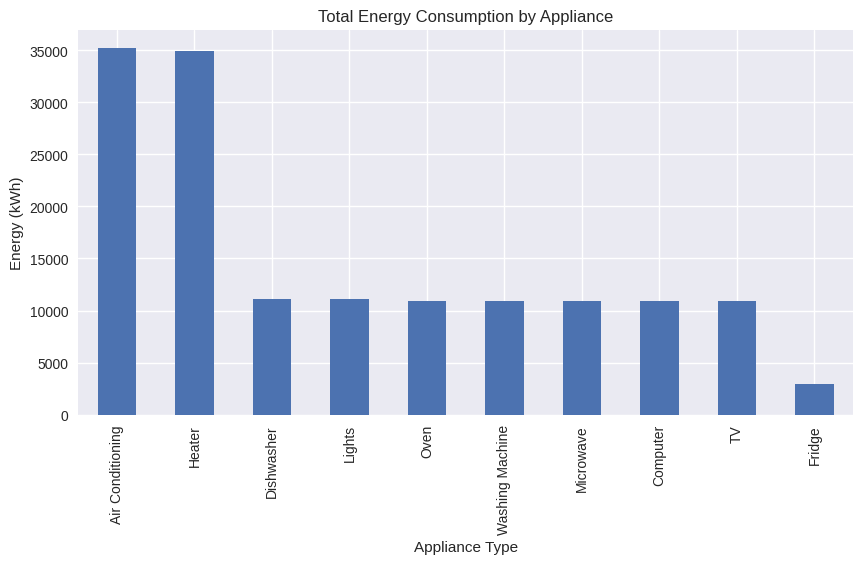

In [35]:
device_energy=df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
device_energy.plot(kind='bar')
plt.title("Total Energy Consumption by Appliance")
plt.ylabel("Energy (kWh)")
plt.show()

In [36]:
df['Energy Consumption (kWh)'].describe()

,Energy Consumption (kWh)
count,100000.000000
mean,1.499952
std,1.181176
min,0.100000
25%,0.590000
50%,1.230000
75%,1.870000
max,5.000000


/tmp/ipython-input-3824430663.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Energy Consumption (kWh)'],bins=50)


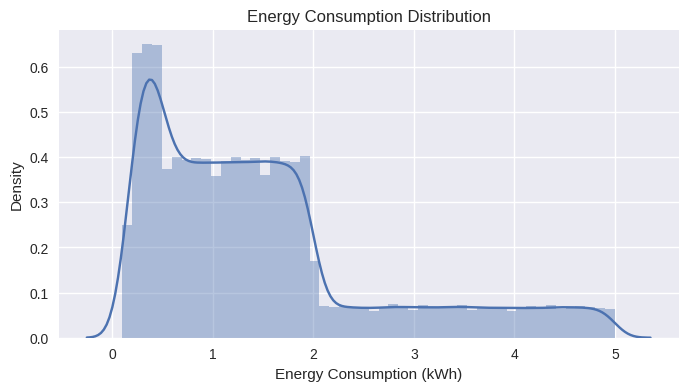

In [37]:
plt.figure(figsize=(8,4))
sns.distplot(df['Energy Consumption (kWh)'],bins=50)
plt.title("Energy Consumption Distribution")
plt.show()

In [38]:
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])



In [39]:
df[['timestamp']].head()

,timestamp
0,2023-12-02 21:12:00
1,2023-08-06 20:11:00
2,2023-11-21 06:39:00
3,2023-01-21 21:56:00
4,2023-08-26 04:31:00


In [40]:
df['timestamp'].dtype

dtype('<M8[ns]')

In [41]:
df=df.drop(['Date','Time'],axis=1)
df=df.set_index('timestamp')


In [42]:
df.index.min(),df.index.max()

(Timestamp('2023-01-01 00:07:00'), Timestamp('2024-01-01 23:53:00'))

In [43]:
df.to_csv("../content/device_level.csv")

In [44]:
df1=pd.read_csv('/content/device_level.csv')
df1.head()

,timestamp,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size
0,2023-12-02 21:12:00,94,Fridge,0.20,-1.0,Fall,2
1,2023-08-06 20:11:00,435,Oven,0.23,31.1,Summer,5
2,2023-11-21 06:39:00,466,Dishwasher,0.32,21.3,Fall,3
3,2023-01-21 21:56:00,496,Heater,3.92,-4.2,Winter,1
4,2023-08-26 04:31:00,137,Microwave,0.44,34.5,Summer,5


In [45]:
df1.index.dtype

dtype('int64')

In [46]:
df1.isnull().sum()

,0
timestamp,0
Home ID,0
Appliance Type,0
Energy Consumption (kWh),0
Outdoor Temperature (°C),0
Season,0
Household Size,0


In [47]:
df1.duplicated().sum()

np.int64(0)

In [48]:
# df1=df1[~df1.duplicated()] removing duplicates

In [49]:
(df1['Energy Consumption (kWh)'] < 0).sum()

np.int64(0)

In [50]:
upper_limit=df['Energy Consumption (kWh)'].quantile(0.99)
df1=df1[df1['Energy Consumption (kWh)'] <= upper_limit]


In [51]:
df1['Appliance Type'].unique()

array(['Fridge', 'Oven', 'Dishwasher', 'Heater', 'Microwave',
       'Air Conditioning', 'Computer', 'TV', 'Washing Machine', 'Lights'],
      dtype=object)

In [52]:
# hourly_df=(df1.groupby('Appliance Type').resample('H')['Energy Consumption (kWh)'].sum().reset_index())

In [53]:
hourly_df=(df.groupby('Appliance Type').resample('H')['Energy Consumption (kWh)'].sum().reset_index())

/tmp/ipython-input-2452177001.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df=(df.groupby('Appliance Type').resample('H')['Energy Consumption (kWh)'].sum().reset_index())


In [54]:
hourly_df.head()

,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01 00:00:00,4.42
1,Air Conditioning,2023-01-01 01:00:00,7.61
2,Air Conditioning,2023-01-01 02:00:00,14.80
3,Air Conditioning,2023-01-01 03:00:00,4.19
4,Air Conditioning,2023-01-01 04:00:00,10.68


In [55]:
hourly_df.shape

(87828, 3)

In [56]:
daily_df=(df.groupby('Appliance Type').resample('D')['Energy Consumption (kWh)'].sum().reset_index())

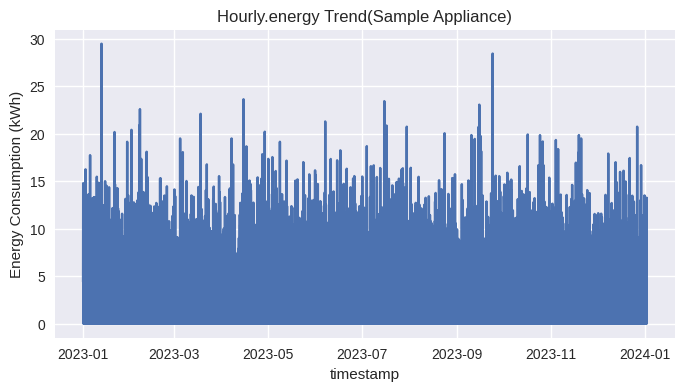

In [57]:
plt.figure(figsize=(8,4))
sns.lineplot(
    data=hourly_df[hourly_df['Appliance Type']==hourly_df['Appliance Type'].iloc[0]],
    x='timestamp',
    y='Energy Consumption (kWh)'
)
plt.title("Hourly.energy Trend(Sample Appliance)")
plt.show()

In [58]:
hourly_df.to_csv("../content/hourly_df.csv")
daily_df.to_csv("../content/daily_df.csv")

In [59]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df1['Energy Consumption (kWh)']=scaler.fit_transform(df1[['Energy Consumption (kWh)']])
print(df1['Energy Consumption (kWh)'])

0        0.021053
1        0.027368
2        0.046316
3        0.804211
4        0.071579
           ...   
99995    0.067368
99996    0.128421
99997    0.031579
99998    0.545263
99999    0.056842
Name: Energy Consumption (kWh), Length: 99049, dtype: float64


In [60]:
hourly_df.info()
hourly_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87828 entries, 0 to 87827
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Appliance Type            87828 non-null  object        
 1   timestamp                 87828 non-null  datetime64[ns]
 2   Energy Consumption (kWh)  87828 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 2.0+ MB


,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01 00:00:00,4.42
1,Air Conditioning,2023-01-01 01:00:00,7.61
2,Air Conditioning,2023-01-01 02:00:00,14.80
3,Air Conditioning,2023-01-01 03:00:00,4.19
4,Air Conditioning,2023-01-01 04:00:00,10.68


In [61]:
hourly_df=hourly_df.set_index('timestamp')

In [62]:
hourly_df['hour']=hourly_df.index.hour
hourly_df['day']=hourly_df.index.day
hourly_df['weekday']=hourly_df.index.weekday
hourly_df['month']=hourly_df.index.month


In [63]:
hourly_df['lag1']=hourly_df['Energy Consumption (kWh)'].shift(1)
hourly_df['lag24']=hourly_df['Energy Consumption (kWh)'].shift(2)


In [64]:
hourly_df['rolling_mean']=hourly_df['Energy Consumption (kWh)'].rolling(window=24).mean()

In [65]:
hourly_df=hourly_df.dropna()

In [66]:
appliances=hourly_df['Appliance Type'].unique()

In [67]:
print(f"Total Applliances detected: {len(appliances)}")
print("Appliances ",appliances)

Total Applliances detected: 10
Appliances  ['Air Conditioning' 'Computer' 'Dishwasher' 'Fridge' 'Heater' 'Lights'
 'Microwave' 'Oven' 'TV' 'Washing Machine']


In [68]:
for appliance in appliances:
  print(f"\n Processing appliance:{appliance}")
  appliance_df=hourly_df[
      hourly_df['Appliance Type']==appliance].copy()
  x=appliance_df.drop(['Energy Consumption (kWh)'],axis=1)
  y=appliance_df['Energy Consumption (kWh)']
  split_index=int(len(appliance_df)*0.8)
  x_train=x.iloc[:split_index]
  x_test=x.iloc[:split_index]
  y_train=y.iloc[:split_index]
  y_test=y.iloc[:split_index]
  x_train.to_csv(f"../content/{appliance}_x_train.csv",index=False)
  x_test.to_csv(f"../content/{appliance}_x_test.csv",index=False)
  y_train.to_csv(f"../content/{appliance}_y_train.csv",index=False)
  y_test.to_csv(f"../content/{appliance}_y_test.csv",index=False)
print("\n Feature Enigineeering completed for all the appliances")


 Processing appliance:Air Conditioning

 Processing appliance:Computer

 Processing appliance:Dishwasher

 Processing appliance:Fridge

 Processing appliance:Heater

 Processing appliance:Lights

 Processing appliance:Microwave

 Processing appliance:Oven

 Processing appliance:TV

 Processing appliance:Washing Machine

 Feature Enigineeering completed for all the appliances


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
data_path = "/content/"
files = os.listdir(data_path)
appliances = sorted({
    f.replace("X_train_", "").replace(".csv", "")
    for f in files
    if f.startswith("X_train_")
})
print(f"Detected appliances: {appliances}")
# Detected appliances: ['Air Conditioning', 'Computer', 'Dishwasher',
# 'Fridge', 'Heater', 'Lights', 'Microwave', 'Oven', 'TV', 'Washing Machine']
results = []
for appliance in appliances:

    print(f"\nTraining Linear Regression for: {appliance}")

    X_train = pd.read_csv(f"{data_path}X_train_{appliance}.csv")
    X_test  = pd.read_csv(f"{data_path}X_test_{appliance}.csv")
    y_train = pd.read_csv(f"{data_path}y_train_{appliance}.csv").values.ravel()
    y_test  = pd.read_csv(f"{data_path}y_test_{appliance}.csv").values.ravel()

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Appliance": appliance,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

    plt.figure(figsize=(10,4))
    plt.plot(y_test, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linestyle="--")
    plt.title(f"Linear Regression Prediction – {appliance}")
    plt.xlabel("Time Steps")
    plt.ylabel("Energy Consumption (kWh)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    joblib.dump(
        model,
        f"../models/linear_regression_{appliance}.pkl"
    )
results_df = pd.DataFrame(results)
results_df

Detected appliances: []


""
